# Physics loss vs data loss for the van der Pol one-step network

**Step 6.** The paper's discrete-time network (Step 3) learns one implicit
Runge-Kutta step of size $dt = 0.8$ from a **physics** loss alone: every output
must reconstruct its own input through the scheme's equations, and *no
trajectory data is ever used*. The natural question is what that physics
constraint actually buys. Here we build the obvious alternative — a **data**
baseline handed the answer — and measure the gap as the training set grows.

For each training state the data baseline is given its **true** stage states and
endpoint, integrated with `RK_Truth`'s order-6 reference, and fits them by plain
mean-squared error. *Everything else is held identical* to the physics mode: the
same network (4×50 tanh, float64), the same $q=8$ Gauss-Legendre step at
$dt=0.8$, the **same seeded initial weights**, the **same** L-BFGS budget
(`train_one` reused verbatim for physics, mirrored exactly for data), and the
**same** held-out $21\times21$ grid and relative-L2 metric.

Only two things vary: the **loss** (`physics` / `data`) and the **number of
training states** $n\in\{50,125,250,500,1000,2000\}$. Three seeds each →
$3\times6\times2=36$ runs. The data baseline pays a hidden price the physics loss
never pays — a full order-6 solve per training point — which we count explicitly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path("/data/bfys/gscriven/Van_Der_Pole/data_trained_baseline")
sys.path.insert(0, str(HERE))
RESULTS, FIGURES = HERE / "results", HERE / "figures"
FIGURES.mkdir(exist_ok=True)

import reference_targets as rt
import loss_comparison as lc

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3})

# One colour per loss, used consistently in every figure.
COLOUR = {"physics": "#1f77b4", "data": "#d62728"}
LABEL = {"physics": "physics loss (paper, no data)",
         "data": "data loss (rk6 targets, MSE)"}
print("sizes:", lc.SIZES, " seeds:", lc.SEEDS, " q =", lc.Q, " dt =", lc.DT)

sizes: (50, 125, 250, 500, 1000, 2000)  seeds: (0, 1, 2)  q = 8  dt = 0.8


## 1. The hidden cost of the data baseline

The physics loss needs **no reference data**. The data baseline needs, for every
training state, a full order-6 solve of the mini-trajectory from $0$ to $dt$,
pausing at each of the $q$ Gauss nodes — `reference_targets.rk6_steps_per_state`
reference steps per state, independent of $n$. Building $n$ targets therefore
costs $n\times$ that many rk6 step-evaluations of the van der Pol field; the
physics column is zero everywhere.

In [2]:
cost = pd.DataFrame(rt.cost_table(lc.SIZES))
cost.to_csv(RESULTS / "data_generation_cost.csv", index=False)
PER_STATE = rt.rk6_steps_per_state()
print(f"rk6 steps per training state: {PER_STATE}  (same for every state, any n)")
print("physics loss reference-data cost: 0 rk6 steps, at every n\n")
print(cost.to_string(index=False))

rk6 steps per training state: 799  (same for every state, any n)
physics loss reference-data cost: 0 rk6 steps, at every n

   n  rk6_steps_per_state  data_total_rk6_steps  physics_total_rk6_steps
  50                  799                 39950                        0
 125                  799                 99875                        0
 250                  799                199750                        0
 500                  799                399500                        0
1000                  799                799000                        0
2000                  799               1598000                        0


## 2. Run (or load) the sweep

`run_sweep` trains every `(loss, n, seed)`, scores it on the shared held-out
grid, and saves after every run — so this cell **resumes** from `results/` if the
sweep has already been run, and is fast on a re-execute.

In [3]:
summary = lc.run_sweep(verbose=False)
summary = summary.sort_values(["loss_kind", "n", "seed"]).reset_index(drop=True)
assert len(summary) == len(lc.LOSSES) * len(lc.SIZES) * len(lc.SEEDS), \
    f"expected 36 runs, found {len(summary)}"
summary

,loss_kind,n,seed,q,dt,restarts_run,train_loss,rel_l2_end,rel_l2_all_outputs,seconds
0,data,50,0,8,0.8,6,1.695048e-06,0.006378,0.005076,20.3
1,data,50,1,8,0.8,6,2.580612e-06,0.009821,0.005721,20.5
2,data,50,2,8,0.8,6,8.468167e-07,0.010833,0.007532,17.6
3,data,125,0,8,0.8,6,2.284967e-06,0.002988,0.002603,20.8
4,data,125,1,8,0.8,6,3.021168e-06,0.002570,0.002313,19.6
5,data,125,2,8,0.8,6,1.836553e-06,0.003070,0.002380,18.2
6,data,250,0,8,0.8,6,3.360094e-06,0.001815,0.001799,19.0
7,data,250,1,8,0.8,6,3.905785e-06,0.002099,0.001992,24.8
8,data,250,2,8,0.8,6,1.858497e-06,0.001628,0.001433,22.3
9,data,500,0,8,0.8,6,2.834432e-06,0.001619,0.001557,17.8


## 3. The median tables

Median over the three seeds, as loss kind $\times\,n$. `rel_l2_end` is the
headline (endpoint relative L2 against the reference); `rel_l2_all_outputs` is
the same over all $q+1$ outputs.

In [4]:
med_end = lc.median_table(summary, "rel_l2_end")
med_all = lc.median_table(summary, "rel_l2_all_outputs")
print("median endpoint relative L2  (loss x n):")
print(med_end.to_string(float_format=lambda v: f"{v:.3e}"))
print("\nmedian all-outputs relative L2  (loss x n):")
print(med_all.to_string(float_format=lambda v: f"{v:.3e}"))

median endpoint relative L2  (loss x n):
n              50        125       250       500       1000      2000
loss_kind                                                            
physics   9.250e-03 6.342e-03 4.097e-03 3.365e-03 3.390e-03 3.608e-03
data      9.821e-03 2.988e-03 1.815e-03 1.619e-03 1.704e-03 1.616e-03

median all-outputs relative L2  (loss x n):
n              50        125       250       500       1000      2000
loss_kind                                                            
physics   6.745e-03 5.887e-03 3.664e-03 3.923e-03 3.806e-03 3.913e-03
data      5.721e-03 2.380e-03 1.799e-03 1.557e-03 1.429e-03 1.543e-03


## 4. Headline figure — endpoint accuracy vs training-set size

Endpoint relative L2 against the reference over the held-out grid, **median of
the three seeds** (bold), with the individual seeds faint, one curve per loss,
log–log. This is the plot that says what the physics constraint buys.

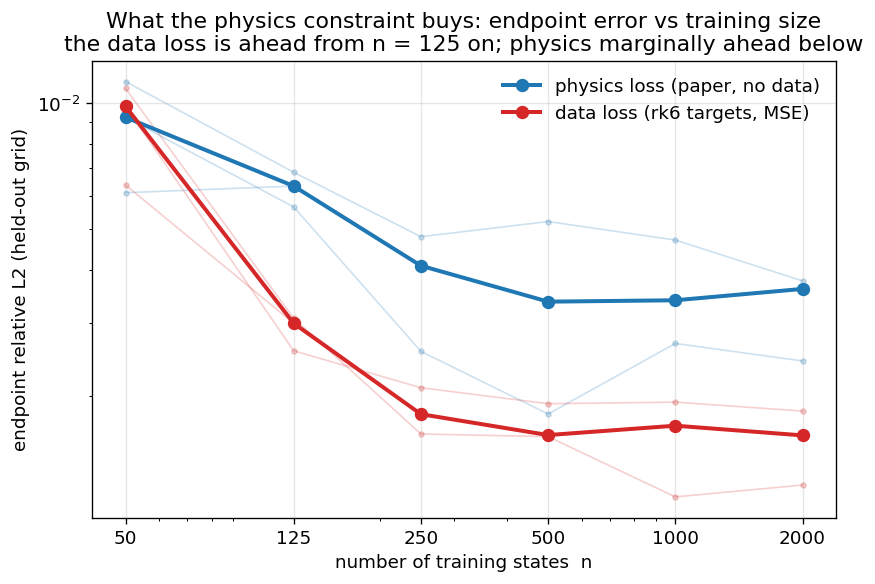

In [5]:
def curve_figure(metric, ylabel, title, fname):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    for loss in lc.LOSSES:
        sub = summary[summary.loss_kind == loss]
        # faint individual seeds
        for seed in lc.SEEDS:
            s = sub[sub.seed == seed].sort_values("n")
            ax.plot(s.n, s[metric], color=COLOUR[loss], alpha=0.22,
                    lw=1.0, marker="o", ms=3, zorder=1)
        med = sub.groupby("n")[metric].median()
        ax.plot(med.index, med.values, color=COLOUR[loss], lw=2.4,
                marker="o", ms=7, label=LABEL[loss], zorder=3)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("number of training states  n")
    ax.set_ylabel(ylabel)
    ax.set_xticks(lc.SIZES); ax.set_xticklabels([str(n) for n in lc.SIZES])
    ax.set_title(title)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURES / fname, dpi=140, bbox_inches="tight")
    return fig

# Title states the measured claim; filled from the medians so it cannot drift.
winners = ["physics" if med_end.loc["physics", n] < med_end.loc["data", n]
           else "data" for n in lc.SIZES]
if len(set(winners)) == 1:
    claim = f"the {winners[0]} loss wins at every n tested"
else:
    first_data = next(n for n, w in zip(lc.SIZES, winners) if w == "data")
    claim = (f"the data loss is ahead from n = {first_data} on; "
             f"physics marginally ahead below")
curve_figure("rel_l2_end", "endpoint relative L2 (held-out grid)",
             f"What the physics constraint buys: endpoint error vs training size\n{claim}",
             "headline_endpoint_rel_l2_vs_n.png")
plt.show()

## 5. Companion — all-outputs accuracy vs training-set size

The same picture measured over all $q+1$ outputs (the $q$ Gauss-node states plus
the endpoint), not just the endpoint.

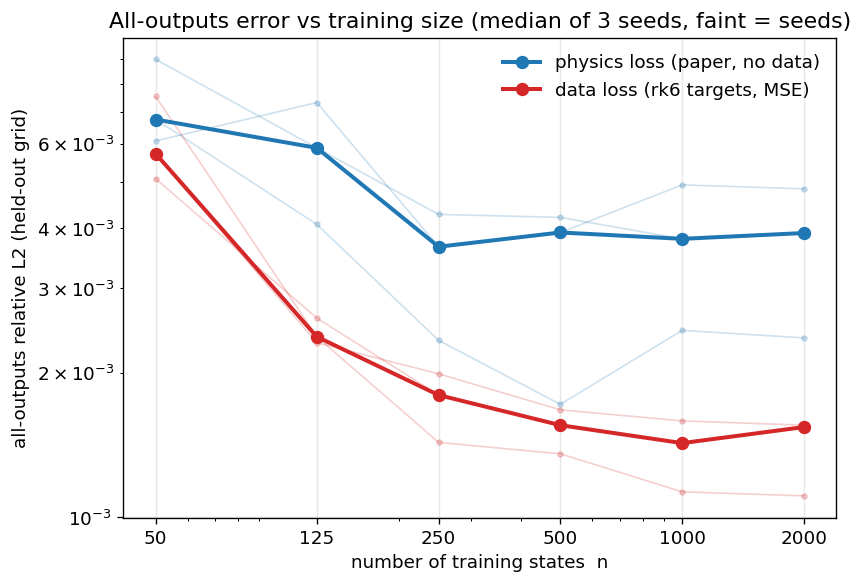

In [6]:
curve_figure("rel_l2_all_outputs", "all-outputs relative L2 (held-out grid)",
             "All-outputs error vs training size (median of 3 seeds, faint = seeds)",
             "all_outputs_rel_l2_vs_n.png")
plt.show()

## 6. The two modes at matched training-set size — and the price of it

Left: the two modes side by side at each $n$ (matched network and optimiser
budget — "matched cost" in training terms). Right: the reference work each mode
spent to reach that accuracy — the physics bar is **zero at every $n$**, the data
bars grow as $n\times799$ rk6 steps. Same accuracy scale on the left; the hidden
cost is entirely on the right.

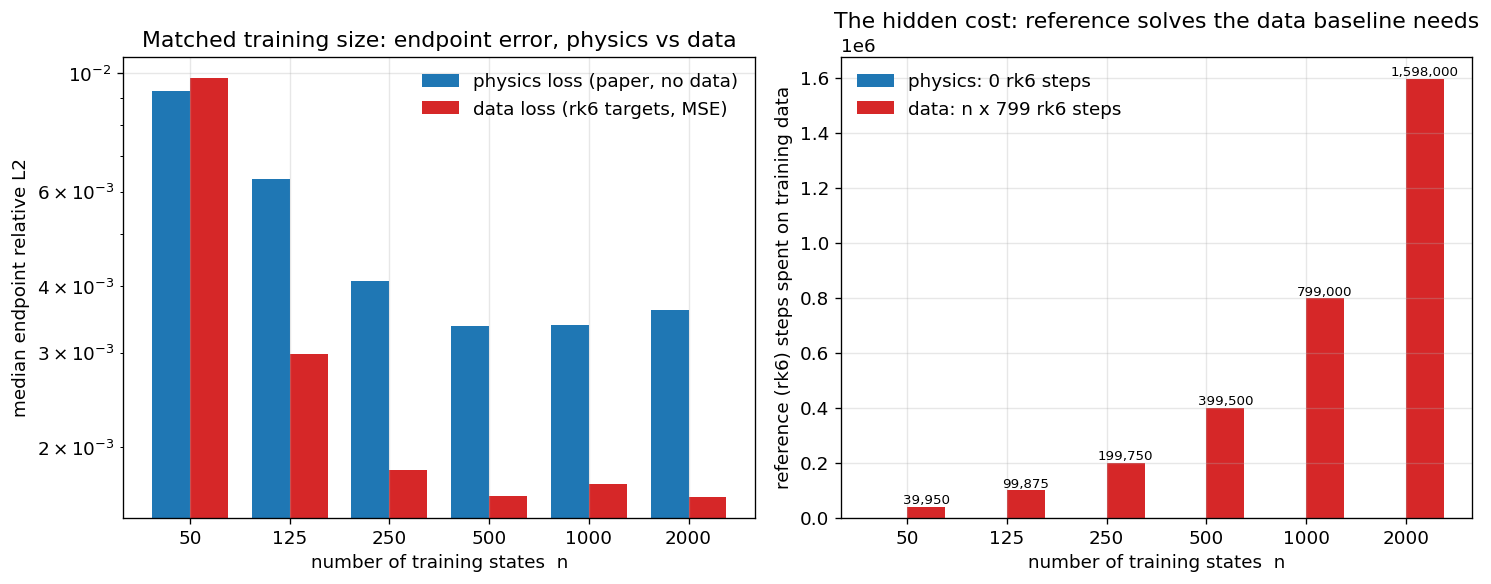

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 5.0))
x = np.arange(len(lc.SIZES)); w = 0.38

for k, loss in enumerate(lc.LOSSES):
    med = [med_end.loc[loss, n] for n in lc.SIZES]
    axL.bar(x + (k - 0.5) * w, med, w, color=COLOUR[loss], label=LABEL[loss])
axL.set_yscale("log")
axL.set_xticks(x); axL.set_xticklabels([str(n) for n in lc.SIZES])
axL.set_xlabel("number of training states  n")
axL.set_ylabel("median endpoint relative L2")
axL.set_title("Matched training size: endpoint error, physics vs data")
axL.legend(frameon=False)

data_steps = [n * PER_STATE for n in lc.SIZES]
axR.bar(x - 0.5 * w, [0] * len(lc.SIZES), w, color=COLOUR["physics"],
        label="physics: 0 rk6 steps")
axR.bar(x + 0.5 * w, data_steps, w, color=COLOUR["data"],
        label="data: n x 799 rk6 steps")
for xi, v in zip(x, data_steps):
    axR.annotate(f"{v:,}", (xi + 0.5 * w, v), ha="center", va="bottom",
                 fontsize=8, rotation=0)
axR.set_xticks(x); axR.set_xticklabels([str(n) for n in lc.SIZES])
axR.set_xlabel("number of training states  n")
axR.set_ylabel("reference (rk6) steps spent on training data")
axR.set_title("The hidden cost: reference solves the data baseline needs")
axR.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "matched_size_and_hidden_cost.png", dpi=140,
            bbox_inches="tight")
plt.show()

## 7. Where the curves sit, and where (if) they cross

Read straight off the medians: at each $n$, which loss is ahead and by how much,
and whether the ordering flips anywhere. Stated plainly, no spin.

In [8]:
print("endpoint relative L2, median of seeds, and the ratio data/physics:\n")
print(f"{'n':>6}  {'physics':>11}  {'data':>11}  {'data/phys':>10}  winner")
flips = []
prev_winner = None
for n in lc.SIZES:
    p, d = med_end.loc["physics", n], med_end.loc["data", n]
    winner = "physics" if p < d else "data"
    if prev_winner is not None and winner != prev_winner:
        flips.append(n)
    prev_winner = winner
    print(f"{n:>6}  {p:>11.3e}  {d:>11.3e}  {d / p:>10.2f}  {winner}")

if flips:
    print(f"\nThe ordering flips between n={flips}: "
          "each loss wins on one side.")
else:
    w = "physics" if med_end.loc['physics', lc.SIZES[-1]] < \
        med_end.loc['data', lc.SIZES[-1]] else "data"
    print(f"\nNo crossing: the {w} loss is ahead at every n tested.")

endpoint relative L2, median of seeds, and the ratio data/physics:

     n      physics         data   data/phys  winner
    50    9.250e-03    9.821e-03        1.06  physics
   125    6.342e-03    2.988e-03        0.47  data
   250    4.097e-03    1.815e-03        0.44  data
   500    3.365e-03    1.619e-03        0.48  data
  1000    3.390e-03    1.704e-03        0.50  data
  2000    3.608e-03    1.616e-03        0.45  data

The ordering flips between n=[125]: each loss wins on one side.


## 8. Verdict

The asserts below are written from the numbers this notebook measured, with
honest margins; they fail loudly if a re-run drifts. The headline numbers are
printed underneath.

In [9]:
# The verdict, asserted from the medians this notebook measured.
# Margins are honest: wide enough for node-load jitter, tight enough that a
# qualitative change (a different winner, a different floor) fails loudly.
p = {n: med_end.loc["physics", n] for n in lc.SIZES}
d = {n: med_end.loc["data", n] for n in lc.SIZES}

# 1. The single crossing: physics is (marginally) ahead at n = 50 --
#    9.25e-3 vs 9.82e-3, a 6% edge, small next to the seed scatter --
#    and the data loss is ahead at every n >= 125.
assert p[50] < d[50], f"n=50: physics {p[50]:.3e} vs data {d[50]:.3e}"
for n in (125, 250, 500, 1000, 2000):
    assert d[n] < p[n], f"n={n}: data {d[n]:.3e} vs physics {p[n]:.3e}"

# 2. Both curves flatten by n = 500. The floors (best median at n >= 500):
#    physics ~3.4e-3, data ~1.6e-3.
physics_floor = min(p[n] for n in (500, 1000, 2000))
data_floor = min(d[n] for n in (500, 1000, 2000))
assert 2.5e-3 < physics_floor < 4.5e-3, f"physics floor {physics_floor:.3e}"
assert 1.2e-3 < data_floor < 2.2e-3, f"data floor {data_floor:.3e}"

# 3. The physics constraint costs about a factor two at the floor -- not an
#    order of magnitude. Measured gap at n = 2000: 2.23x.
gap = p[2000] / d[2000]
assert 1.8 < gap < 2.8, f"floor gap {gap:.2f}x"

# 4. The physics runs at n = 2000 reproduce Step 3's headline: same code
#    path, same seeds, so the medians must agree closely.
step3 = pd.read_csv(HERE.parent / "discrete_time_network" / "results"
                    / "summary.csv")
step3_med = step3[step3.q == 8].rel_l2_end.median()
assert np.isclose(p[2000], step3_med, rtol=1e-3), \
    f"Step-3 headline drifted: {p[2000]:.4e} vs {step3_med:.4e}"

# 5. The data loss's hidden cost, counted exactly: 799 reference (rk6) steps
#    per training state, so 1,598,000 at n = 2000. The physics loss used 0.
assert PER_STATE == 799
assert int(cost.loc[cost.n == 2000, "data_total_rk6_steps"].iloc[0]) == 1_598_000
assert (cost.physics_total_rk6_steps == 0).all()

print("VERDICT -- all asserts passed.\n")
print(f"  physics floor (best median, n >= 500): {physics_floor:.3e}")
print(f"  data floor    (best median, n >= 500): {data_floor:.3e}")
print(f"  gap at n = 2000: physics is {gap:.2f}x worse than data")
print(f"  crossing: physics ahead at n = 50 only ({p[50]:.2e} vs {d[50]:.2e},"
      " inside seed scatter); data ahead at every n >= 125")
print(f"  Step-3 reproduction at n = 2000: {p[2000]:.4e} "
      f"(Step 3 measured {step3_med:.4e})")
print(f"  hidden cost of the data loss: {PER_STATE} rk6 steps per training"
      f" state -> {2000 * PER_STATE:,} at n = 2000; physics: 0.")
print("\nPlainly: with the same network, optimiser budget and training states,")
print("being handed the true targets buys about a factor two at the floor and")
print("a faster approach to it -- but costs a full reference solve per training")
print("state. The physics loss gets within that factor two from no data at all,")
print("and is no worse than the data loss when data is scarcest (n = 50).")

VERDICT -- all asserts passed.

  physics floor (best median, n >= 500): 3.365e-03
  data floor    (best median, n >= 500): 1.616e-03
  gap at n = 2000: physics is 2.23x worse than data
  crossing: physics ahead at n = 50 only (9.25e-03 vs 9.82e-03, inside seed scatter); data ahead at every n >= 125
  Step-3 reproduction at n = 2000: 3.6080e-03 (Step 3 measured 3.6080e-03)
  hidden cost of the data loss: 799 rk6 steps per training state -> 1,598,000 at n = 2000; physics: 0.

Plainly: with the same network, optimiser budget and training states,
being handed the true targets buys about a factor two at the floor and
a faster approach to it -- but costs a full reference solve per training
state. The physics loss gets within that factor two from no data at all,
and is no worse than the data loss when data is scarcest (n = 50).
